# Import des bibliothèques

In [2]:
import pandas as pd
import pathlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import gensim
from collections import defaultdict
from gensim import corpora
import re
from gensim.models import LdaModel
import spacy
from spacy.tokenizer import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from pathlib import Path
import sys

In [3]:
text = open("Corpus_textes/1879_ Goncourt_Les-Freres-Zemganno_N.txt").read()
nlp = spacy.load("fr_core_news_sm")

## Tokenisation et nettoyage des données

```python

In [4]:
doc= nlp(text)
tokens = [
    token.text for token in doc if not token.is_stop 
    and not token.is_punct 
    and not token.like_num 
    and not token.is_space]

print(tokens[:20])

['Edmond', 'Goncourt', 'Frères', 'Zemganno', 'MADAME', 'ALPHONSE', 'DAUDET', 'pleine', 'campagne', 'pied', 'poteau', 'octroi', 'dressé', 'carrefour', 'croisaient', 'routes', 'passait', 'château', 'Louis', 'XIII']


## Lementisation

In [5]:
tokens_propres= [
    token.lemma_ for token in doc if not token.is_stop
    and not token.is_punct
    and not token.is_space]

In [6]:
print(tokens_propres[:20])

['Edmond', 'Goncourt', 'frère', 'Zemganno', 'monsieur', 'ALPHONSE', 'DAUDET', 'pleine', 'campagn', 'pied', 'poteau', 'octroi', 'dresser', 'carrefour', 'croiser', 'route', 'passer', 'château', 'Louis', 'xiii']


# Avec Gensim Recherche champs lexicaux sur un seul texte (Gouncourt : Freres Zemganno)

## Sans stop words et avec ponctuation, chiffres et espaces

In [7]:
taille_bloc = 200
documents = [tokens_propres[i:i + taille_bloc] for i in range(0, len(tokens_propres), taille_bloc)]

print(f"texte découpé en {len(documents)} mini-documents.")

id2word = corpora.Dictionary(documents)
corpus = [id2word.doc2bow(doc) for doc in documents]
lda_model = LdaModel(corpus=corpus,    
                     id2word=id2word,  # Dictionnaire pour mapper les IDs aux mots
                     num_topics=3,  # Nombre de thèmes à extraire
                     random_state=42, # Pour la reproductibilité
                     passes=50, # Nombre de passes sur le corpus pour l'entraînement
                     iterations=100) # Nombre d'itérations pour la convergence

print("-Champs Lexicaux trouvés-")
for idx, topic in lda_model.print_topics(-1):
    print(f"Thème {idx}: {topic}")

texte découpé en 111 mini-documents.
-Champs Lexicaux trouvés-
Thème 0: 0.005*"faire" + 0.005*"petit" + 0.005*"frère" + 0.005*"grand" + 0.005*"Gianni" + 0.004*"jour" + 0.004*"Nello" + 0.003*"bien" + 0.003*"être" + 0.003*"chose"
Thème 1: 0.009*"Gianni" + 0.008*"petit" + 0.008*"Nello" + 0.007*"frère" + 0.007*"faire" + 0.004*"jour" + 0.004*"grand" + 0.004*"donner" + 0.004*"homme" + 0.004*"être"
Thème 2: 0.009*"Gianni" + 0.008*"frère" + 0.008*"petit" + 0.007*"Nello" + 0.007*"faire" + 0.006*"jour" + 0.005*"pied" + 0.005*"chose" + 0.004*"dire" + 0.004*"saut"


## Avec stop words,  et sans ponctuation, chiffres et espaces

In [8]:

stopwords = {"nello", "gianni", "faire", "dire", "aller", "bien", "grand", "petit", "choir", "voir"}
tokens_super_propres = [
    token.lemma_ for token in doc 
    if not token.is_stop 
    and token.is_alpha 
    and token.pos_ in ["NOUN", "ADJ"] # garder que les noms et adjectifs
    and token.lemma_ not in stopwords]

taille_bloc = 200
documents = [tokens_super_propres[i:i + taille_bloc] for i in range(0, len(tokens_super_propres), taille_bloc)]

print(f" texte découpé en {len(documents)} mini-documents.")

id2word = corpora.Dictionary(documents)
corpus = [id2word.doc2bow(doc) for doc in documents]
lda_model = LdaModel(corpus=corpus, 
                     id2word=id2word, # mapping entre les mots et leurs ids
                     num_topics=3, # nombre de thèmes à trouver
                     random_state=42, # pour la reproductibilité
                     passes=50,  # nombre de passes sur le corpus
                     iterations=100) # nombre d'itérations pour la convergence

print("-Champs Lexicaux trouvés-")
for idx, topic in lda_model.print_topics(-1):
    print(f"Thème {idx}: {topic}")

 texte découpé en 71 mini-documents.
-Champs Lexicaux trouvés-
Thème 0: 0.013*"frère" + 0.008*"jour" + 0.008*"corps" + 0.008*"main" + 0.007*"chose" + 0.006*"pied" + 0.006*"jeune" + 0.006*"homme" + 0.005*"tête" + 0.005*"jambe"
Thème 1: 0.005*"femme" + 0.005*"homme" + 0.004*"chose" + 0.004*"jour" + 0.004*"frère" + 0.003*"moment" + 0.003*"corps" + 0.003*"voiture" + 0.003*"cheval" + 0.003*"temps"
Thème 2: 0.013*"frère" + 0.009*"jour" + 0.007*"pied" + 0.005*"temps" + 0.005*"chose" + 0.005*"heure" + 0.005*"saut" + 0.005*"fois" + 0.005*"exercice" + 0.005*"moment"


# Utilisation de TF-IDF pour identifier les mots les plus importants

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# On crée un faux corpus avec juste ton texte propre
corpus_test = [" ".join(tokens_super_propres)]

vectorizer = TfidfVectorizer(max_features=20)
tfidf_matrix = vectorizer.fit_transform(corpus_test)

# Récupérer les mots et leurs scores
feature_names = vectorizer.get_feature_names_out()
scores = tfidf_matrix.toarray().flatten()

# Afficher les 20 mots qui définissent vraiment le texte
mots_cles = pd.DataFrame({'mot': feature_names, 'importance': scores}).sort_values(by='importance', ascending=False)
print(mots_cles)

         mot  importance
5      frère    0.502165
9       jour    0.353282
0      chose    0.252344
14      pied    0.249821
10      main    0.237204
1      corps    0.222063
6      homme    0.217016
8      jeune    0.189258
12    moment    0.189258
3      femme    0.184211
16     temps    0.176641
2   exercice    0.171594
18      tour    0.166547
13      oeil    0.156453
19      tête    0.156453
11    milieu    0.148883
4       fois    0.143836
7      jambe    0.141313
15      saut    0.138789
17     terre    0.138789


# Utilsiation de Scikit-learn pour l'analyse de texte

In [10]:
vectorizer = TfidfVectorizer(max_features=25, min_df=1) # On garde les 25 mots les plus importants
tfidf_matrix = vectorizer.fit_transform(tokens_propres)

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster = kmeans.fit_predict(tfidf_matrix)

In [12]:
print(cluster)

[0 0 1 ... 0 0 0]


In [13]:
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(tfidf_matrix)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",3
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [14]:
def afficher_topics(model, vectorizer, n_top_words):
    mots = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(model.components_):
        message = f"Thème #{topic_idx} : "
        message += " | ".join([mots[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# On affiche les 10 mots principaux des themes 
afficher_topics(lda, vectorizer, 10)

Thème #0 : nello | faire | grand | chose | bien | homme | donner | coup | venir | temps
Thème #1 : gianni | frère | pied | main | femme | moment | mettre | venir | temps | jeune
Thème #2 : petit | jour | être | cirque | corps | dire | voir | jeune | temps | venir


## Test sur un corpus de textes naturalistes

In [15]:
dossier_path = Path("/Users/morganr/Champs_lexicaux_N-A/Corpus_textes")

donnees = []

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On détermine le label selon le nom du fichier
    label = "naturaliste" if "_N" in fichier.name else "non-naturaliste"
        
    if label == "naturaliste":
        donnees.append({
            "nom_fichier": fichier.name,
            "texte_brut": contenu,
            "label": label
         })
    else :
        pass 

# Création du tableau de bord (DataFrame)
df = pd.DataFrame(donnees)
print(f"{len(df)} textes chargés avec succès.")

5 textes chargés avec succès.


In [16]:
df

,nom_fichier,texte_brut,label
0,1885_Adam_Chair-molle_N.txt,\n\n\nPaul Adam\n\n\n\nChair molle\n\n\nRoman ...,naturaliste
1,1886_Rosny_Nell-Horn_N.txt,\n\n\n\n\nPREMIÈRE PARTIE\nAu fond de la pelou...,naturaliste
2,1879_ Goncourt_Les-Freres-Zemganno_N.txt,\n\n\n\nEdmond de Goncourt\n\n\n\nLes Frères Z...,naturaliste
3,1881_Lemmonier_un-mâle_N.txt,\n\nCamille Lemonnier\n\n\n\n\nUn mâle\n\n\n\n...,naturaliste
4,1882_Cladel_Ompdrailles_N.txt,\nLéon Cladel.\n\nOmpdrailles le Tombeau-des-L...,naturaliste


In [17]:
nlp = spacy.load("fr_core_news_sm")
def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return " ".join(tokens)

# on nettoyage des 10 textes d'un coup
df['texte_propre'] = df['texte_brut'].apply(preprocess_text)
 
# les resultats
print(df[['label', 'texte_propre']].head())

         label                                       texte_propre
0  naturaliste  paul adam chair mou roman naturaliste partie g...
1  naturaliste  partie fond pelouse lisière massif sombre tota...
2  naturaliste  edmond goncourt frère zemganno monsieur alphon...
3  naturaliste  camille lemonnier mâle roman postface leduc ad...
4  naturaliste  léon cladel ompdraille lbe ompdraille carrier ...


In [18]:
vectorizer = TfidfVectorizer(max_features=50, min_df=1) # On garde les 50 mots les plus importants et qui apparaissent au moins dans 1 document
tfidf_matrix = vectorizer.fit_transform(df['texte_propre'])

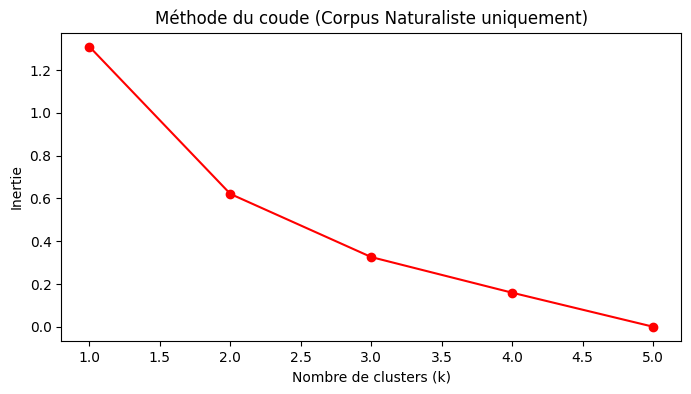

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inerties = []
# Avec 5 textes, on ne peut pas tester k=10. On teste de 1 à 6.
K_range = range(1, 6) 

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=20) # n_init=20 pour une meilleure convergence
    model.fit(tfidf_matrix) # On entraîne le modèle KMeans sur la matrice TF-IDF
    inerties.append(model.inertia_) # On stocke l'inertie (somme des distances au carré des points à leur centre de cluster) pour chaque k

# Affichage du graphique
plt.figure(figsize=(8, 4))
plt.plot(K_range, inerties, 'ro-') # 'ro-' pour des points rouges reliés
plt.xlabel('Nombre de clusters (k)') 
plt.ylabel('Inertie')
plt.title('Méthode du coude (Corpus Naturaliste uniquement)')
plt.show()

In [20]:
kmeans = KMeans(n_clusters=2, random_state=42) # On choisit k=2 car c'est le point où l'inertie commence à diminuer moins rapidement (le "coude" du graphique)
df['cluster'] = kmeans.fit_predict(tfidf_matrix) # On ajoute une colonne "cluster" à notre DataFrame avec les étiquettes de cluster attribuées à chaque texte

lda = LatentDirichletAllocation(n_components=2, random_state=42) # On choisit n_components=2 pour correspondre au nombre de clusters trouvé avec KMeans
lda.fit(tfidf_matrix)  # On entraîne le modèle LDA sur la matrice TF-IDF

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",2
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [21]:
def afficher_topics(model, vectorizer, n_top_words):
    mots = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(model.components_):
        message = f"Thème #{topic_idx} : "
        message += " | ".join([mots[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# On affiche les 10 mots principaux pour nos 2 thèmes
afficher_topics(lda, vectorizer, 10)

Thème #0 : nelly | petit | être | bien | faire | avoir | voir | aller | grand | venir
Thème #1 : bien | faire | être | petit | voir | avoir | nelly | main | jour | aller


# Test sur les 5 textes naturalistes et 5 textes non-naturalistes

In [22]:
dossier_path = Path("/Users/morganr/Champs_lexicaux_N-A/Corpus_textes")

donnees = []

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On détermine le label selon le nom du fichier
    label = "naturaliste" if "_N" in fichier.name else "non-naturaliste"
        
    donnees.append({
            "nom_fichier": fichier.name,
            "texte_brut": contenu,
            "label": label
        })
      
         

# Création du tableau de bord (DataFrame)
df_2 = pd.DataFrame(donnees)
print(f"{len(df_2)} textes chargés avec succès.")

10 textes chargés avec succès.


In [23]:
df_2

,nom_fichier,texte_brut,label
0,1883_Lesueur_L'amant-de-Genevieve_A.txt,PREMIÈRE PARTIE Chapitre I. Il y avait bien tr...,non-naturaliste
1,1882_Albalat_L'inassouvie-roman-intime_A.txt,\nLES CHASTETÉS IMPURESPREMIERE PARTIEI.\nJe n...,non-naturaliste
2,1882_Verne_L-Ecole-des-Robinsons_A.txt,"I« Île à vendre, au comptant, frais en sus, au...",non-naturaliste
3,1885_Adam_Chair-molle_N.txt,\n\n\nPaul Adam\n\n\n\nChair molle\n\n\nRoman ...,naturaliste
4,1886_Rosny_Nell-Horn_N.txt,\n\n\n\n\nPREMIÈRE PARTIE\nAu fond de la pelou...,naturaliste
5,1884_Rachilde_Monsieur-Venus_A.txt,RACHILDE MONSIEUR VÉNUS A Monsieur LÉO D'ORF...,non-naturaliste
6,1879_ Goncourt_Les-Freres-Zemganno_N.txt,\n\n\n\nEdmond de Goncourt\n\n\n\nLes Frères Z...,naturaliste
7,1881_Lemmonier_un-mâle_N.txt,\n\nCamille Lemonnier\n\n\n\n\nUn mâle\n\n\n\n...,naturaliste
8,1881_Barbey-d-Aurevilly_Une-histoire-sans-nom_...,"Mon cher Paul Bourget, Je veux mettre votre n...",non-naturaliste
9,1882_Cladel_Ompdrailles_N.txt,\nLéon Cladel.\n\nOmpdrailles le Tombeau-des-L...,naturaliste


In [24]:
# On définit une liste de mots "vides" personnalisée
blacklist = {"faire", "rester", "aller", "voir", "avoir", "être", "bien", "petit", "grand", "jeune"}

def nettoyage_lexical(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc 
        if not token.is_stop 
        and token.is_alpha 
        and token.pos_ in ["NOUN", "ADJ"]  # On ignore les verbes et les noms propres
        and token.ent_type_ == ""         # On ignore les Entités Nommées (Nello, Gianni...)
        and token.lemma_ not in blacklist
    ]
    return " ".join(tokens)

# Applique ça sur tes 10 textes (5 Nat + 5 Non-Nat)
df_2['texte_propre'] = df_2['texte_brut'].apply(nettoyage_lexical)

In [25]:
# On sépare les deux groupes
textes_nat = " ".join(df[df_2['label'] == 'naturaliste']['texte_propre'])
textes_non_nat = " ".join(df[df_2['label'] == 'non-naturaliste']['texte_propre'])

/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_52524/240123919.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  textes_nat = " ".join(df[df_2['label'] == 'naturaliste']['texte_propre'])
/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_52524/240123919.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  textes_non_nat = " ".join(df[df_2['label'] == 'non-naturaliste']['texte_propre'])


In [26]:
# On utilise les 10 textes pour avoir du contraste
tfidf = TfidfVectorizer(max_features=50)
matrix = tfidf.fit_transform(df_2['texte_propre'])
mots = tfidf.get_feature_names_out()

# On crée un tableau des scores moyens par label
scores_par_label = pd.DataFrame(matrix.toarray(), columns=mots)
scores_par_label['label'] = df_2['label']
resultat = scores_par_label.groupby('label').mean()

print("\nChamp lexical spécifique aux Naturalistes")
print(resultat.loc['naturaliste'].sort_values(ascending=False).head(10))

print("\nChamp lexical spécifique aux Non-Naturalistes")
print(resultat.loc['non-naturaliste'].sort_values(ascending=False).head(10))


Champ lexical spécifique aux Naturalistes
main     0.240005
jour     0.231947
homme    0.229737
oeil     0.211863
fille    0.196576
bon      0.178886
tête     0.177616
fois     0.177499
femme    0.175548
vieux    0.162274
Name: naturaliste, dtype: float64

Champ lexical spécifique aux Non-Naturalistes
jour     0.259128
homme    0.250887
femme    0.236950
main     0.226404
fille    0.201148
heure    0.193411
oeil     0.185937
bon      0.178244
chose    0.158971
tête     0.153367
Name: non-naturaliste, dtype: float64


# Utilisation de Pymotifs

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

from motifs.pipeline import Pipeline
from motifs.plots import plot_motif_histogram, plot_tf_idf
from motifs.pca import pca_transform
import time
import os
import spacy_udpipe
import shutil

import spacy

from motifs.pipeline import Pipeline
from motifs.plots import plot_motif_histogram, plot_tf_idf
from motifs.pca import pca_transform
import time


In [31]:
from motifs.config import PKG_DATA_PATH

# Define the path of the corpus
corpus_dir = "/Users/morganr/Champs_lexicaux_N-A/Corpus_textes"
tokens_dir = None

token_type = "motif"

# Define the feature on which to perform PCA analysis
feature = {"name": "tfidf", "params": {"normalize": True, "smartirs": "nfc"}}
# Please check gensim doc for the parameters definition. SMARTIRS
# corresponds to the standard notation available at https://en.wikipedia.org/wiki/SMART_Information_Retrieval_System

# n-gram length
n = 5

In [41]:
# La destination secrète où le moteur linguistique attend son dictionnaire
destination = spacy_udpipe.utils.get_path("fr")

# Les endroits où le fichier se trouve probablement sur ton Mac
chemin_bureau = os.path.expanduser("~/Desktop/french-gsd-ud-2.5-191206.udpipe")

# Recherche du fichier
if os.path.exists(chemin_bureau):
    vrai_fichier = chemin_bureau
else:
    vrai_fichier = None

# Installation
if vrai_fichier:
    print(f"-> Fichier trouvé ici : {vrai_fichier}")
    shutil.copy(vrai_fichier, destination)
    print("Le vrai dictionnaire a été placé au bon endroit !")
    
    nlp = spacy_udpipe.load("fr")
    print("le moteur est prêt !")
else:
    print("Fichier introuvable. Essaie de le glisser sur ton Bureau et relance cette cellule.")

-> Fichier trouvé ici : /Users/morganr/Desktop/french-gsd-ud-2.5-191206.udpipe
Le vrai dictionnaire a été placé au bon endroit !
le moteur est prêt !


In [42]:
pipeline = Pipeline(token_type, corpus_dir=corpus_dir, tokens_dir=tokens_dir, save=False)

[PyMotifs-Logger:tokenizer.py:299] - [52524] - 2026-04-14 11:18:36 - DEBUG - Steps to go 10: tokenizing 1883_Lesueur_L'amant-de-Genevieve_A.txt...
[PyMotifs-Logger:tokenizer.py:317] - [52524] - 2026-04-14 11:19:39 - DEBUG - Done with 1883_Lesueur_L'amant-de-Genevieve_A.txt in 63.45 seconds.
[PyMotifs-Logger:tokenizer.py:299] - [52524] - 2026-04-14 11:19:39 - DEBUG - Steps to go 9: tokenizing 1882_Albalat_L'inassouvie-roman-intime_A.txt...
[PyMotifs-Logger:tokenizer.py:317] - [52524] - 2026-04-14 11:20:56 - DEBUG - Done with 1882_Albalat_L'inassouvie-roman-intime_A.txt in 77.05 seconds.
[PyMotifs-Logger:tokenizer.py:299] - [52524] - 2026-04-14 11:20:56 - DEBUG - Steps to go 8: tokenizing 1882_Verne_L-Ecole-des-Robinsons_A.txt...
[PyMotifs-Logger:tokenizer.py:317] - [52524] - 2026-04-14 11:22:03 - DEBUG - Done with 1882_Verne_L-Ecole-des-Robinsons_A.txt in 66.65 seconds.
[PyMotifs-Logger:tokenizer.py:299] - [52524] - 2026-04-14 11:22:03 - DEBUG - Steps to go 7: tokenizing 1885_Adam_Chair

In [43]:
t1 = time.time()
# Transform to n_grams
pipeline.transform_to_ngrams(n)
t2 = time.time()
print(f"Execution time: {t2 - t1:.4f} secs")

[PyMotifs-Logger:features.py:49] - [54353] - 2026-04-14 11:31:22 - DEBUG - Steps to go 10
[PyMotifs-Logger:features.py:49] - [54354] - 2026-04-14 11:31:22 - DEBUG - Steps to go 9
[PyMotifs-Logger:features.py:49] - [54352] - 2026-04-14 11:31:22 - DEBUG - Steps to go 8
[PyMotifs-Logger:features.py:49] - [54350] - 2026-04-14 11:31:22 - DEBUG - Steps to go 7
[PyMotifs-Logger:features.py:49] - [54357] - 2026-04-14 11:31:22 - DEBUG - Steps to go 5
[PyMotifs-Logger:features.py:49] - [54351] - 2026-04-14 11:31:22 - DEBUG - Steps to go 6
[PyMotifs-Logger:features.py:49] - [54359] - 2026-04-14 11:31:23 - DEBUG - Steps to go 4
[PyMotifs-Logger:features.py:49] - [54355] - 2026-04-14 11:31:23 - DEBUG - Steps to go 2
[PyMotifs-Logger:features.py:49] - [54358] - 2026-04-14 11:31:23 - DEBUG - Steps to go 3
[PyMotifs-Logger:features.py:49] - [54356] - 2026-04-14 11:31:23 - DEBUG - Steps to go 1


Execution time: 16.6892 secs


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, '1886_Rosny_Nell-Horn_N'),
  Text(1, 0, "1882_Albalat_L'inassouvie-roman-intime_A"),
  Text(2, 0, '1881_Lemmonier_un-mâle_N'),
  Text(3, 0, '1882_Cladel_Ompdrailles_N'),
  Text(4, 0, '1882_Verne_L-Ecole-des-Robinsons_A'),
  Text(5, 0, "1883_Lesueur_L'amant-de-Genevieve_A"),
  Text(6, 0, '1879_ Goncourt_Les-Freres-Zemganno_N'),
  Text(7, 0, '1885_Adam_Chair-molle_N'),
  Text(8, 0, '1884_Rachilde_Monsieur-Venus_A'),
  Text(9, 0, '1881_Barbey-d-Aurevilly_Une-histoire-sans-nom_A')])

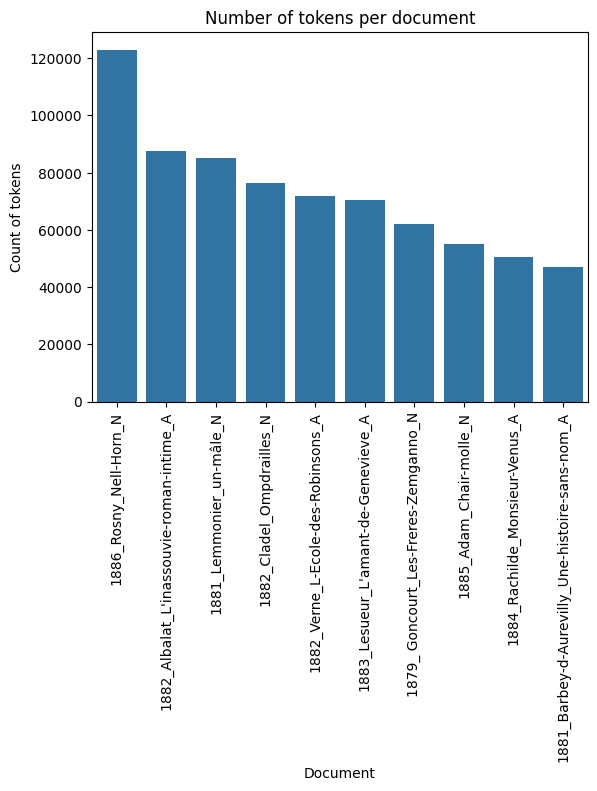

In [53]:
sns.countplot(pipeline.ngrams, x="doc", order=pipeline.ngrams['doc'].value_counts().index)
plt.title("Number of tokens per document")
plt.xlabel("Document")
plt.ylabel("Count of tokens")
plt.xticks(rotation=90)
